# Filtered Facial Encoding Hamming Weight Experiments #

## Tunes the Angle of error tolerance to filter 'bad' hyperplanes ##

In [1]:
import face_recognition
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.stats import norm
import math
import os
import random
import string
from scipy.special import betainc, betaincinv
from tqdm import tqdm
import pandas as pd
import json
from bsp import CosineLSH

### Now we define the image to encoding functionality for an particular image ###

In [3]:
def images_to_encoding(path):
    image = face_recognition.load_image_file(path)
    
    if(len(face_recognition.face_encodings(image))==0): 
        return [None]

    if(len(face_recognition.face_encodings(image)[0])!=0):
        return face_recognition.face_encodings(image)[0]

    return [None]

In [4]:
# Define the following function that given a parent folder, I can iterate all entries in the parent folder by their name! 
# NOTE: this is a generator so you need to initiate the generator function first!

def subfolder_names(parent_folder):
    # Iterate over all entries in parent folder
    for entry in os.listdir(parent_folder):
        full_path = os.path.join(parent_folder, entry)
        if os.path.isdir(full_path):
            yield full_path


# Now I want to define a function that given a path, choose k images from the folder 
def pick_k_images(folder_path, k):
    # List all files in the folder
    all_files = [f for f in os.listdir(folder_path) 
                 if os.path.isfile(os.path.join(folder_path, f)) 
                 and f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    if len(all_files) == 0:
        return []  # no images found
    
    # If k > number of available images, just return all images shuffled
    if k >= len(all_files):
        random.shuffle(all_files)
        return [os.path.join(folder_path, f) for f in all_files]
    
    # Randomly pick k images
    chosen_files = random.sample(all_files, k)
    
    # Return full paths
    return [os.path.join(folder_path, f) for f in chosen_files]

# Now I want to define a generator to generate all files within a particular folder
def images_in_folder(folder_path):
    for filename in os.listdir(folder_path):
        full_path = os.path.join(folder_path, filename)
        if os.path.isfile(full_path) and filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            yield full_path



# Section 0: Optimize Data #

In this section, we need to ensure there's no crazy data (filter) and put them in ram to ensure fast processing

1. We will build a dictionary data structure to support this
    - for each folder I will specify a max of faces and put them into the data structure (these will be the encoded version)

2. For future experiments I only need to consult this data structure

In [5]:
# Just in case we have additional dataset to test on
folder_extracted="train"

# define the official data structure in RAM 

facial_data=dict()

# define the maximum for each folder (bascially set a cap) -> this can be tuned

cap=100

### Now the Databse Building Process ##

1. We iterate through all the folders 

2. For each folder we encode the first CAP images 

3. Store into the DB

In [6]:
all_folders=[image for image in subfolder_names("faces")]

In [ ]:
for folder in tqdm(all_folders): # for a specific person
    facial_data[folder]=[]

    counter=0

    for image in images_in_folder(folder):
        encoding=images_to_encoding(image)

        if encoding[0]==None:
            # print("bad")
            continue

        facial_data[folder].append(encoding)

        if counter==cap: break
        else: counter+=1

In [29]:
with open(f"data_{folder_extracted}.json", "a") as f:
    json.dump(facial_data, f, indent=4, default=lambda o:
              o.tolist() if isinstance(o, np.ndarray) else str(o))

### In order to save us time for future ##

We only need to do this once and we will store this Data into a json so I can later extract it

In [6]:
def restore(obj):
    if isinstance(obj, list):
        # If it's a list of numbers, convert to numpy array
        if all(isinstance(x, (int, float)) for x in obj):
            return np.array(obj)
        # Otherwise recurse element-wise
        return [restore(x) for x in obj]
    if isinstance(obj, dict):
        return {k: restore(v) for k, v in obj.items()}
    return obj

with open(f"data_{folder_extracted}.json", "r") as f:
    facial_data_loaded = json.load(f)

facial_data= restore(facial_data_loaded)

### Some Helper Functions ###

In [7]:
def mean_faces(encodings):
    # now to deal with for batch ==1
    if len(encodings)==1:
        return encodings[0]
    
    # Now deal with the regular batch
    arr = np.array(encodings, dtype=float)
    return arr.mean(axis=0)

def rand_subset(arr, k):
    if k > len(arr):
        raise ValueError("k cannot be larger than the length of arr")
    return random.sample(arr, k)

def rand_select(avoidance=None):
    if avoidance==None: 
        return random.randint(0,100)
    else:
        selected=random.randint(0,100)
        while selected==avoidance:
            selected=random.randint(0,100)
        return selected

# Section 1: Expected Size of IS #

In this section I want to calculate the expected value of the error set (IS)

In [8]:
hyperplane=32
dimension=128
degree_of_tolerance=[i for i in range(1,10)]

result_theory=[]
result_practice=[]

def expected_filtered_count(k, d, tolerance_degrees):
    """
    Calculates the expected number of hyperplanes filtered out.
    
    Args:
        k: Total number of hyperplanes
        d: Dimension of the vector space
        tolerance_degrees: The angle alpha (tolerance)
    """
    # Convert to radians
    alpha_rad = np.radians(tolerance_degrees)
    
    # Calculate x for the beta function: x = sin^2(alpha)
    x = np.sin(alpha_rad)**2
    
    # Parameters for the beta distribution
    a = 0.5
    b = (d - 1) / 2
    
    # Probability P(|dot| < threshold)
    probability = betainc(a, b, x)
    
    return k * probability

for degree in degree_of_tolerance:
    result_theory.append(expected_filtered_count(hyperplane,dimension,degree))

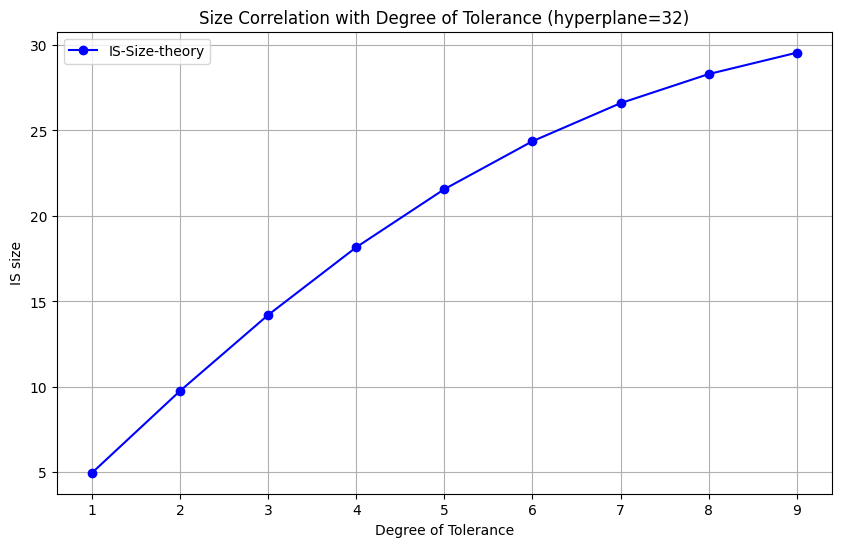

In [9]:
plt.figure(figsize=(10, 6))  # Optional: Set figure size (width, height)
plt.plot([each*1 for each in degree_of_tolerance], result_theory, marker='o', linestyle='-', color='b', label='IS-Size-theory')
# plt.plot([each*1 for each in degree_of_tolerance], result_practice, marker='o', linestyle='--', color='r', label='IS-Size-Actual')
# 3. Add labels
plt.title(f"Size Correlation with Degree of Tolerance (hyperplane={hyperplane})")
plt.xlabel("Degree of Tolerance")
plt.ylabel("IS size")
plt.grid(True)
plt.legend()

# 4. Show the plot
plt.show()

## Section 2.1: Test normalness among a single individual ##

We further test if face are normally distributed amount a single individual's mean and with std-deviation, I will define a helper function

In [14]:
import scipy.stats as stats

def test_angular_normality(faces_array):
    """
    Tests if the angles between faces and their centroid are normally distributed.
    
    Args:
        faces_array: (N, D) numpy array of facial embeddings.
    """
    # 1. Calculate Centroid
    centroid = np.mean(faces_array, axis=0)
    
    # 2. Normalize everything to unit length (Critical for Cosine/Angles)
    # Normalize centroid
    centroid = centroid / np.linalg.norm(centroid)
    
    # Normalize faces
    norms = np.linalg.norm(faces_array, axis=1, keepdims=True)
    faces_normalized = faces_array / norms
    
    # 3. Calculate Angles (in Degrees)
    # Dot product of normalized vectors = Cosine Similarity
    # Clip to [-1, 1] to avoid numerical errors with arccos
    cosines = np.dot(faces_normalized, centroid)
    cosines = np.clip(cosines, -1.0, 1.0)
    
    angles_deg = np.degrees(np.arccos(cosines))
    
    # 4. Statistical Tests
    print(f"--- Normality Test Report (N={len(angles_deg)}) ---")
    print(f"Mean Angle: {np.mean(angles_deg):.4f}°")
    print(f"Std Dev:    {np.std(angles_deg):.4f}°")
    
    # Shapiro-Wilk Test (Good for N < 5000)
    # Null Hypothesis: Data IS normally distributed.
    # If p-value < 0.05, we REJECT the null (It is NOT normal).
    shapiro_stat, shapiro_p = stats.shapiro(angles_deg)
    
    print("-" * 40)
    print(f"Shapiro-Wilk Test:")
    print(f"  Statistic: {shapiro_stat:.4f}")
    print(f"  p-value:   {shapiro_p:.4e}")
    
    if shapiro_p > 0.001:
        print("  RESULT: likely Normal (Gaussian).")
    else:
        print("  RESULT: NOT Normal (Deviates significantly).")

    # 5. Visual Check (Histogram + Q-Q Plot) 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Histogram
    ax1.hist(angles_deg, bins=30, density=True, alpha=0.6, color='b', label='Observed')
    # ax1.hist(cosines, bins=30, density=True, alpha=0.6, color='b', label='Observed')
    
    # Overlay the ideal Normal Curve
    xmin, xmax = ax1.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, np.mean(angles_deg), np.std(angles_deg))
    ax1.plot(x, p, 'k', linewidth=2, label='Ideal Normal')
    ax1.set_title('Histogram of Angles')
    ax1.set_xlabel('Angle (Degrees)')
    ax1.legend()
    
    # Q-Q Plot (Quantile-Quantile)
    # Points should lie on the red line if Normal
    stats.probplot(angles_deg, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot')
    
    plt.tight_layout()
    plt.show()
    
    return angles_deg

--- Normality Test Report (N=101) ---
Mean Angle: 9.5445°
Std Dev:    1.4995°
----------------------------------------
Shapiro-Wilk Test:
  Statistic: 0.9695
  p-value:   1.9268e-02
  RESULT: likely Normal (Gaussian).


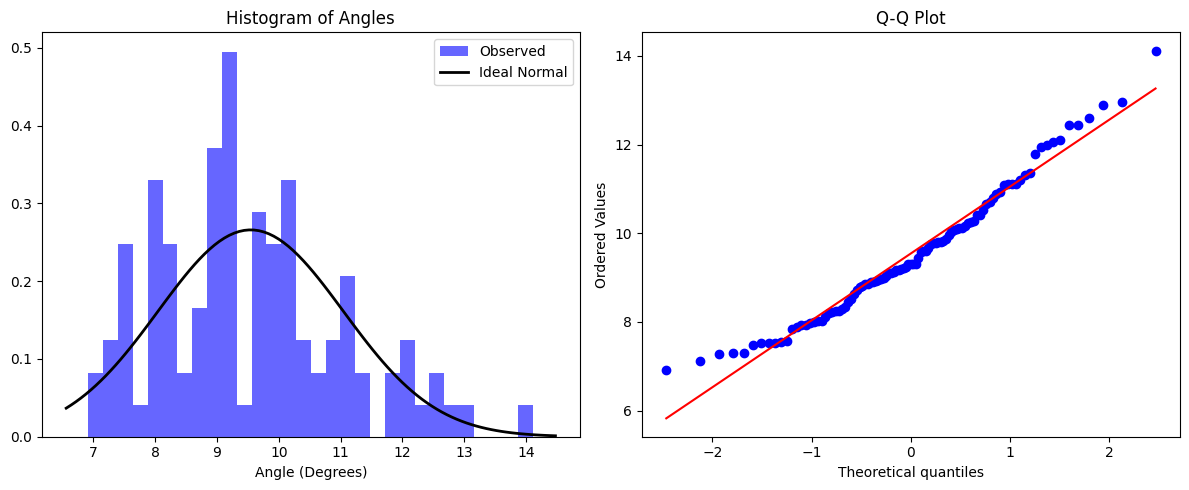

array([10.02479591,  8.9044006 , 10.07519082,  7.11813268,  8.81990563,
       10.11732871,  9.09959611,  9.17027881,  8.28645284,  9.57034942,
        6.91972971,  8.33296652,  7.83369575, 10.17327313,  9.67337075,
       10.11181754,  7.54992887, 10.26701114, 10.91910007, 10.23820604,
        8.44243759,  9.83244979,  7.93670288,  7.28900617, 12.8836306 ,
        8.02401561,  8.72222602,  8.02395631,  8.95134761,  7.52081322,
        8.63877865, 10.25427218,  7.48264478,  8.97628432,  8.23383974,
       14.11501352,  8.8469488 ,  7.97813534, 12.59888665,  7.2926631 ,
        9.8752313 , 10.66156058,  8.92438082, 11.19508489,  9.77965533,
        7.56567842,  8.89770183,  8.11595295,  9.04600614,  9.23011835,
        9.30336317,  7.28535768,  9.20327902,  8.86544458,  9.22541758,
       11.77927569,  7.52576896, 11.36228501,  8.77803047,  9.76076799,
       12.43594387, 10.41847646,  8.25098847,  7.89375309,  8.19043148,
        9.95136426, 11.11173867, 10.51598966,  8.24718884, 12.09

In [15]:
# select a random folder of a single person and run the test

faces=facial_data[list(facial_data.keys())[rand_select()]]
test_angular_normality(faces)

## Section 2.2 Calculate ($ \mu_{same} $ $\sigma_{same}$), ($ \mu_{diff} $ $\sigma_{diff}$) ##

This will give us the theory bound for fp, fn, when given a particular number of hyperplanes

In [20]:
same_face_vectors=facial_data[list(facial_data.keys())[rand_select()]]
diff_face_vectors=np.array([facial_data[each][rand_select()] for each in facial_data.keys()])

def calculate_angular_stats(vectors, mode='intra'):
    """
    Calculates Mean and Std Dev of angles for facial vectors.
    
    Args:
        vectors (np.array): Shape (N, D) array of N vectors.
        mode (str): 
            'intra' (Same People) -> Measures angles vs. the group Centroid.
            'inter' (Diff People) -> Measures pairwise angles between all vectors.
            
    Returns:
        (float, float): (mean_angle, std_dev_angle) in degrees.
    """
    # 0. Safety: Ensure input is a numpy array
    vectors = np.array(vectors)
    
    # 1. Normalize Vectors (Crucial for Cosine logic)
    # This ensures |v| = 1, so dot product = cosine directly
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    
    # Avoid division by zero
    norms[norms == 0] = 1.0 
    vectors_norm = vectors / norms

    if mode == 'intra':
        # --- SCENARIO 1: SAME PEOPLE (Centroid Logic) ---
        
        # A. Calculate Centroid
        centroid = np.mean(vectors_norm, axis=0)
        
        # B. Normalize Centroid (The average of unit vectors is not unit length!)
        c_norm = np.linalg.norm(centroid)
        if c_norm == 0: return 0.0, 0.0
        centroid = centroid / c_norm
        
        # C. Calculate Cosines (Dot product of each vec with Centroid)
        # Shape: (N,)
        cosines = np.dot(vectors_norm, centroid)
        
        # D. Convert to Angles
        # Clip to [-1, 1] to handle floating point errors like 1.00000002
        cosines = np.clip(cosines, -1.0, 1.0)
        angles = np.degrees(np.arccos(cosines))
        
        return np.mean(angles), np.std(angles)

    elif mode == 'inter':
        # --- SCENARIO 2: DIFFERENT PEOPLE (Pairwise Logic) ---
        
        # A. Calculate Similarity Matrix (All vs All)
        # Shape: (N, N)
        sim_matrix = np.dot(vectors_norm, vectors_norm.T)
        
        # B. Extract Unique Pairs
        # We only want the upper triangle, excluding the diagonal (self-match)
        # k=1 offset excludes the main diagonal
        unique_indices = np.triu_indices_from(sim_matrix, k=1)
        unique_cosines = sim_matrix[unique_indices]
        
        # C. Convert to Angles
        unique_cosines = np.clip(unique_cosines, -1.0, 1.0)
        angles = np.degrees(np.arccos(unique_cosines))
        
        if len(angles) == 0: return 0.0, 0.0
        
        return np.mean(angles), np.std(angles)

    else:
        raise ValueError("Mode must be 'intra' or 'inter'")
    
mu_same,sigma_same=calculate_angular_stats(same_face_vectors,'intra')
mu_diff,sigma_diff=calculate_angular_stats(diff_face_vectors,'inter')

print(f"mu_same={mu_same}, sigma_same={sigma_same}")

print(f"mu_diff={mu_diff}, sigma_diff={sigma_diff}")

mu_same=13.372038516418344, sigma_same=1.8366758470390103
mu_diff=33.94631748499963, sigma_diff=3.8389459916512827


# Section 3： Crossover point(s) for false positive and false negative with bagging mechanism #

1. In this section I will show how the bagging cause the false positive and false negative to change 
2. I also show the theory result 

### Now Define the testing routine function first ###

NOTE: this is only for a single person (randomly chosen)

In [9]:
def testing_single_person_bag(hyperplane, bag_number, probablistic=False, k_bits=None):
    """
    Tests a single random person's FP/FN rates using:
    1. Hashed Bagging (averaged over 30 random initializations)
    2. Regular Angular Distance (mapped to equivalent filtered count)
    
    Now supports k_bits to simulate quantized integer vectors.
    """
    
    # 1. Setup Data & Template
    person_ids = list(facial_data.keys())
    selected_idx = rand_select() 
    selected_id = person_ids[selected_idx]
    
    template = mean_faces(facial_data[selected_id])

    # ---------------------------------------------------------
    # PART A: CipherSpace Testing (Hashed + Bagging)
    # ---------------------------------------------------------
    
    IS_set_hashed = list(range(math.floor(hyperplane*0.5)))
    
    accumulated_fp = np.zeros(len(IS_set_hashed))
    accumulated_fn = np.zeros(len(IS_set_hashed))
    
    iterations = 5
    
    for _ in range(iterations):
        hashing_bags = [CosineLSH(hyperplane, 128) for _ in range(bag_number)]
        # NEW: Pass k_bits to hash
        template_strings = [h.hash(template, k_bits=k_bits) for h in hashing_bags]

        for idx, num_discard in enumerate(IS_set_hashed):
            
            for h in hashing_bags:
                # NEW: Pass k_bits to filter
                h.filter_by_hyperplane(template, num_discard, k_bits=k_bits)
            
            distance_fp = []
            distance_fn = []

            for _ in range(100):
                other_idx = rand_select(selected_idx) 
                other_id = person_ids[other_idx]
                fp_vecs = rand_subset(facial_data[other_id], 2)
                fp_str_vec = mean_faces(fp_vecs)
                
                fn_vecs = rand_subset(facial_data[selected_id], 2)
                fn_str_vec = mean_faces(fn_vecs)

                # NEW: Pass k_bits to hash
                string_fps = [h.hash(fp_str_vec, k_bits=k_bits) for h in hashing_bags]
                string_fns = [h.hash(fn_str_vec, k_bits=k_bits) for h in hashing_bags]

                d_fp = min([hashing_bags[b].filtered_hamming_weights(template_strings[b], string_fps[b]) 
                            for b in range(bag_number)])
                d_fn = min([hashing_bags[b].filtered_hamming_weights(template_strings[b], string_fns[b]) 
                            for b in range(bag_number)])
                
                distance_fp.append(d_fp)
                distance_fn.append(d_fn)

            curr_fp_rate = distance_fp.count(0) / len(distance_fp)
            curr_fn_rate = (len(distance_fn) - distance_fn.count(0)) / len(distance_fn)
            
            accumulated_fp[idx] += curr_fp_rate
            accumulated_fn[idx] += curr_fn_rate

    fp_hashed = (accumulated_fp / iterations).tolist()
    fn_hashed = (accumulated_fn / iterations).tolist()

    # ---------------------------------------------------------
    # PART B: PlainSpace Testing (Regular Angular Distance)
    # ---------------------------------------------------------

    def vector_angle(v1, v2):
        # NEW: If k_bits is active, we MUST quantize the vectors before measuring 
        # their angle to ensure PlainSpace theory perfectly matches CipherSpace reality.
        if k_bits is not None:
            v1 = CosineLSH.quantize_array(v1, k_bits)
            v2 = CosineLSH.quantize_array(v2, k_bits)
            
        v1_u = v1 / np.linalg.norm(v1)
        v2_u = v2 / np.linalg.norm(v2)
        dot = np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)
        return np.degrees(np.arccos(dot))

    def get_degree_from_count(k_filtered, total_dim=128):
        if k_filtered == 0: return 0.0
        if k_filtered >= hyperplane: return 90.0
        prob = k_filtered / hyperplane
        sin_sq_alpha = betaincinv(0.5, (total_dim - 1) / 2.0, prob)
        alpha_rad = np.arcsin(np.sqrt(sin_sq_alpha))
        return np.degrees(alpha_rad)

    IS_set_theory_conversion = IS_set_hashed 
    
    fp_regular = []
    fn_regular = []

    if not probablistic:
        for k in IS_set_hashed:
            equivalent_degree = get_degree_from_count(k, 128)
            fp_count = 0
            fn_count = 0
            total_tests = 300 

            for _ in range(total_tests):
                other_idx = rand_select(selected_idx)
                fp_vec = mean_faces(rand_subset(facial_data[person_ids[other_idx]], 2))
                fn_vec = mean_faces(rand_subset(facial_data[selected_id], 2))

                thresh = 2 * equivalent_degree

                if vector_angle(fn_vec, template) > thresh:
                    fn_count += 1
                
                if vector_angle(fp_vec, template) < thresh:
                    fp_count += 1
            
            fp_regular.append(fp_count / total_tests)
            fn_regular.append(fn_count / total_tests)
    else: 
        for k in IS_set_hashed:
            equivalent_degree = get_degree_from_count(k, 128)
            k_survivors = max(0, hyperplane - k)
            
            sum_prob_fp = 0.0
            sum_prob_fn = 0.0
            total_tests = 300 

            for _ in range(total_tests):
                other_idx = rand_select(selected_idx)
                fp_vec = mean_faces(rand_subset(facial_data[person_ids[other_idx]], 1))
                fn_vec = mean_faces(rand_subset(facial_data[selected_id], 1))
                
                theta_diff = vector_angle(fp_vec, template)
                theta_same = vector_angle(fn_vec, template)
                
                def calc_match_prob(theta, alpha, k_surv, n_bags):
                    if theta <= 2 * alpha:
                        p_single_bit = 1.0 
                    else:
                        p_single_bit = max(0.0, 1.0 - (theta - 2 * alpha) / 180.0)
                    
                    if k_surv == 0: 
                        p_bag_match = 1.0 
                    else:
                        p_bag_match = p_single_bit ** k_surv
                    
                    p_system_match = 1.0 - (1.0 - p_bag_match) ** n_bags
                    return p_system_match

                prob_collision = calc_match_prob(theta_diff, equivalent_degree, k_survivors, bag_number)
                sum_prob_fp += prob_collision
                
                prob_success = calc_match_prob(theta_same, equivalent_degree, k_survivors, bag_number)
                prob_miss = 1.0 - prob_success
                sum_prob_fn += prob_miss
            
            fp_regular.append(sum_prob_fp / total_tests)
            fn_regular.append(sum_prob_fn / total_tests)

    return fp_hashed, fn_hashed, IS_set_hashed, fp_regular, fn_regular, IS_set_theory_conversion


def run_multi_person_hyperplane_experiment(hyperplane, bag_number, num_people=30, probablistic=False, k_bits=None):
    """
    Runs the 'testing_single_person_bag' experiment multiple times 
    and returns the AVERAGED FP/FN curves.
    
    Now explicitly accepts k_bits to test quantization impacts.
    """
    
    total_fp_hash = None
    total_fn_hash = None
    total_fp_reg = None
    total_fn_reg = None
    
    x_axis_values = None
    
    for _ in tqdm(range(num_people), desc=f"Testing {num_people} People (k={k_bits if k_bits else 'Float'})"):
        res = testing_single_person_bag(
            hyperplane=hyperplane, 
            bag_number=bag_number,
            probablistic=probablistic,
            k_bits=k_bits # Pass it down here!
        )
        
        fp_h, fn_h, x_axis_ref, fp_r, fn_r, _ = res
        
        if total_fp_hash is None:
            total_fp_hash = np.zeros_like(fp_h, dtype=float)
            total_fn_hash = np.zeros_like(fn_h, dtype=float)
            total_fp_reg = np.zeros_like(fp_r, dtype=float)
            total_fn_reg = np.zeros_like(fn_r, dtype=float)
            x_axis_values = x_axis_ref 
        
        total_fp_hash += np.array(fp_h)
        total_fn_hash += np.array(fn_h)
        total_fp_reg += np.array(fp_r)
        total_fn_reg += np.array(fn_r)
        
    avg_fp_hash = total_fp_hash / num_people
    avg_fn_hash = total_fn_hash / num_people
    avg_fp_reg = total_fp_reg / num_people
    avg_fn_reg = total_fn_reg / num_people
    
    return avg_fp_hash, avg_fn_hash, avg_fp_reg, avg_fn_reg, x_axis_values

In [10]:
def testing_single_person_angles(hyperplane, bag_number, probablistic=False):
    """
    Tests FP/FN rates using Degrees (0-90) as the X-axis for both methods.
    
    Returns:
        fp_hashed, fn_hashed, degree_range, 
        fp_regular, fn_regular, degree_range
    """
    
    # --- 1. Setup Data & Template ---
    person_ids = list(facial_data.keys())
    selected_idx = rand_select()
    selected_id = person_ids[selected_idx]
    
    # Create Template (mean of 2 random faces)
    # Using 2 as batch size based on your previous snippets
    template = mean_faces(rand_subset(facial_data[selected_id], 1))

    # Define X-axis: 0 to 90 degrees
    degree_range = [i/10 for i in range(250)]

    # ---------------------------------------------------------
    # PART A: CipherSpace Testing (Hashed + Bagging)
    # ---------------------------------------------------------
    print("--------- Begin CipherSpace Testing (Angular) ----------------")
    
    accumulated_fp = np.zeros(len(degree_range))
    accumulated_fn = np.zeros(len(degree_range))
    iterations = 5  # Averaging over 5 random initializations
    
    for _ in (range(iterations)):
        # 1. Initialize random bags
        hashing_bags = [CosineLSH(hyperplane, 128) for _ in range(bag_number)]
        template_strings = [h.hash(template) for h in hashing_bags]

        for idx, degree in enumerate(degree_range):
            
            # A. Apply Filtering using your angular method
            for h in hashing_bags:
                h.filter_out_bad_ones(template, degree)
            
            distance_fp = []
            distance_fn = []

            # B. Test against 100 random pairs
            for _ in range(100):
                # Negative Sample
                other_idx = rand_select(selected_idx) 
                fp_vec = mean_faces(rand_subset(facial_data[person_ids[other_idx]], 1))
                
                # Positive Sample
                fn_vec = mean_faces(rand_subset(facial_data[selected_id], 1))

                # Hash
                string_fps = [h.hash(fp_vec) for h in hashing_bags]
                string_fns = [h.hash(fn_vec) for h in hashing_bags]

                # Hamming Distances (Bagging: Take Min)
                # Note: filter_out_bad_ones sets self.filtered_indices inside the object
                d_fp = min([hashing_bags[b].filtered_hamming_weights(template_strings[b], string_fps[b]) 
                            for b in range(bag_number)])
                d_fn = min([hashing_bags[b].filtered_hamming_weights(template_strings[b], string_fns[b]) 
                            for b in range(bag_number)])
                
                distance_fp.append(d_fp)
                distance_fn.append(d_fn)

            # C. Rates
            curr_fp_rate = distance_fp.count(0) / len(distance_fp)
            curr_fn_rate = (len(distance_fn) - distance_fn.count(0)) / len(distance_fn)
            
            accumulated_fp[idx] += curr_fp_rate
            accumulated_fn[idx] += curr_fn_rate

    fp_hashed = (accumulated_fp / iterations).tolist()
    fn_hashed = (accumulated_fn / iterations).tolist()

    # ---------------------------------------------------------
    # PART B: PlainSpace Testing (Regular Angular Distance)
    # ---------------------------------------------------------
    print("--------- CipherSpace Done, Begin PlainSpace Testing ----------------")

    def vector_angle(v1, v2):
        v1_u = v1 / np.linalg.norm(v1)
        v2_u = v2 / np.linalg.norm(v2)
        dot = np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)
        return np.degrees(np.arccos(dot))
    
    # Helper to calculate expected survivors for a given angle
    def get_expected_survivors(degree, N, dim=128):
        if degree <= 0: return N
        if degree >= 90: return 0
        
        alpha_rad = np.radians(degree)
        # Probability a plane falls INSIDE the tolerance zone (and is filtered)
        # Formula: betainc(0.5, (d-1)/2, sin^2(alpha))
        prob_filtered = betainc(0.5, (dim - 1) / 2.0, np.sin(alpha_rad)**2)
        
        # Survivors = Total * (1 - prob_filtered)
        return max(0, N * (1.0 - prob_filtered))

    fp_regular = []
    fn_regular = []

    if not probablistic:
        # --- DETERMINISTIC/HARD THRESHOLD MODE ---
        for degree in degree_range:
            thresh = 2 * degree
            fp_count = 0
            fn_count = 0
            total_tests = 300
            
            for _ in range(total_tests):
                other_idx = rand_select(selected_idx)
                fp_vec = mean_faces(rand_subset(facial_data[person_ids[other_idx]], 1))
                fn_vec = mean_faces(rand_subset(facial_data[selected_id], 1))
                
                if vector_angle(fn_vec, template) > thresh: fn_count += 1
                if vector_angle(fp_vec, template) < thresh: fp_count += 1
            
            fp_regular.append(fp_count / total_tests)
            fn_regular.append(fn_count / total_tests)
            
    else:
        # --- PROBABILISTIC MODE ---
        for degree in degree_range:
            
            # 1. Determine Parameters directly from loop
            alpha = degree
            # Theory: How many planes survive this angle on average?
            k_survivors = get_expected_survivors(alpha, hyperplane)
            
            sum_prob_fp = 0.0
            sum_prob_fn = 0.0
            total_tests = 300 

            for _ in range(total_tests):
                other_idx = rand_select(selected_idx)
                fp_vec = mean_faces(rand_subset(facial_data[person_ids[other_idx]], 1))
                fn_vec = mean_faces(rand_subset(facial_data[selected_id], 1))
                
                theta_diff = vector_angle(fp_vec, template)
                theta_same = vector_angle(fn_vec, template)
                
                # --- Helper: Calculate System Match Probability ---
                def calc_match_prob(theta, a, k_surv, n_bags):
                    # 1. Single Bit Match Probability
                    if theta <= 2 * a:
                        p_single_bit = 1.0 
                    else:
                        p_single_bit = max(0.0, 1.0 - (theta - 2 * a) / 180.0)
                    
                    # 2. Bag Match Probability
                    # Note: We use fractional k_survivors here, which works mathematically for expectation
                    if k_surv <= 0.001: 
                        p_bag_match = 1.0 # 0 survivors = empty set = match
                    else:
                        p_bag_match = p_single_bit ** k_surv
                    
                    # 3. System Match Probability
                    p_system_match = 1.0 - (1.0 - p_bag_match) ** n_bags
                    return p_system_match

                # Calculate
                prob_collision = calc_match_prob(theta_diff, alpha, k_survivors, bag_number)
                sum_prob_fp += prob_collision
                
                prob_success = calc_match_prob(theta_same, alpha, k_survivors, bag_number)
                prob_miss = 1.0 - prob_success
                sum_prob_fn += prob_miss
            
            fp_regular.append(sum_prob_fp / total_tests)
            fn_regular.append(sum_prob_fn / total_tests)

    return fp_hashed, fn_hashed, degree_range, fp_regular, fn_regular, degree_range

def run_multi_person_experiment(hyperplane, bag_number, num_people=30, probablistic=False):
    """
    Runs the experiment multiple times and returns the AVERAGED FP and FN curves.
    Dynamically handles the x-axis length.
    """
    
    # Initialize accumulators as None (we will set size after first run)
    total_fp_hash = None
    total_fn_hash = None
    total_fp_reg = None
    total_fn_reg = None
    
    # We will capture the actual x-axis values from the function
    x_axis_values = None
    
    print(f"Running Averaged Experiment over {num_people} people...")
    
    for i in tqdm(range(num_people)):
        # Run the single person test
        res = testing_single_person_angles(
            hyperplane=hyperplane, 
            bag_number=bag_number, 
            probablistic=probablistic
        )
        
        fp_h, fn_h, x_axis_h, fp_r, fn_r, _ = res
        
        # On the VERY FIRST iteration, initialize our zero-arrays with the correct shape
        if total_fp_hash is None:
            total_fp_hash = np.zeros_like(fp_h, dtype=float)
            total_fn_hash = np.zeros_like(fn_h, dtype=float)
            total_fp_reg = np.zeros_like(fp_r, dtype=float)
            total_fn_reg = np.zeros_like(fn_r, dtype=float)
            x_axis_values = x_axis_h # Save the x-axis for plotting later
        
        # Accumulate results
        total_fp_hash += np.array(fp_h)
        total_fn_hash += np.array(fn_h)
        total_fp_reg += np.array(fp_r)
        total_fn_reg += np.array(fn_r)
        
    # Calculate Averages
    avg_fp_hash = total_fp_hash / num_people
    avg_fn_hash = total_fn_hash / num_people
    avg_fp_reg = total_fp_reg / num_people
    avg_fn_reg = total_fn_reg / num_people
    
    return avg_fp_hash, avg_fn_hash, avg_fp_reg, avg_fn_reg, x_axis_values

In [11]:
def find_crossover(x_axis, fp_rates, fn_rates):
    """
    Finds the intersection point (x, y) where FP matches FN.
    Uses linear interpolation for precision between discrete points.
    """
    x_axis = np.array(x_axis)
    fp_rates = np.array(fp_rates)
    fn_rates = np.array(fn_rates)
    
    # Calculate difference
    diff = fp_rates - fn_rates
    
    # Find indices where sign changes (FP crosses FN)
    # usually FN starts high and FP starts low, so diff starts negative and goes positive
    # We look for where diff > 0
    cross_indices = np.where(np.diff(np.sign(diff)))[0]
    
    if len(cross_indices) == 0:
        return None, None # No intersection found
    
    # Take the first crossing
    idx = cross_indices[0]
    
    # --- Linear Interpolation ---
    # We have two points: (x1, d1) and (x2, d2)
    # We want to find x where d = 0
    
    x1, x2 = x_axis[idx], x_axis[idx+1]
    y_fp1, y_fp2 = fp_rates[idx], fp_rates[idx+1]
    y_fn1, y_fn2 = fn_rates[idx], fn_rates[idx+1]
    
    # Difference at points
    d1 = y_fp1 - y_fn1
    d2 = y_fp2 - y_fn2
    
    # Fraction of distance from x1 to x2
    # If d1 is -0.1 and d2 is 0.1, we are exactly in the middle (0.5)
    fraction = abs(d1) / (abs(d1) + abs(d2))
    
    x_cross = x1 + fraction * (x2 - x1)
    
    # Interpolate the Y value (Rate) at that X
    # We can use either FP or FN slope, they should meet at the same Y
    y_cross = y_fp1 + fraction * (y_fp2 - y_fp1)
    
    return x_cross, y_cross

## Section ??: Convergence ##

Note that the theory and the experiment does not match: WHY 

They actually converge eventually, but this requires the number of hyperplanes "fill" the whole hyper-ball

Generating Theoretical Baseline...
Running Experiment for N=64...
Running Experiment for N=512...
Running Experiment for N=4096...
Calculating Theory for N=4096...


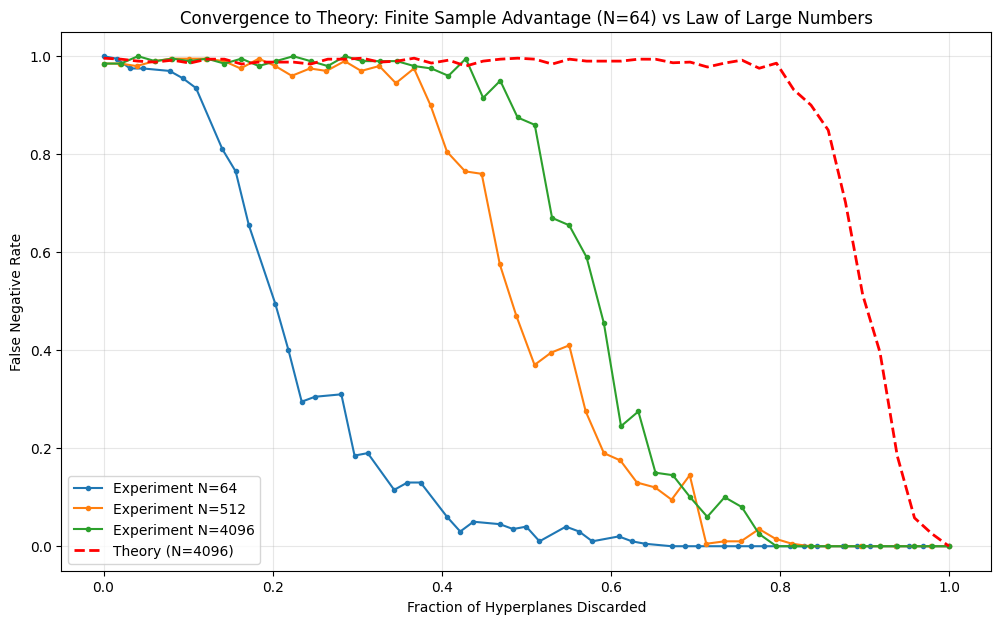

In [18]:
def run_convergence_experiment(bag_number=1, batch_size=1):
    def vector_angle(v1, v2):
        v1_u = v1 / np.linalg.norm(v1)
        v2_u = v2 / np.linalg.norm(v2)
        dot = np.clip(np.dot(v1_u, v2_u), -1.0, 1.0)
        return np.degrees(np.arccos(dot))
    
    # We will test these sizes. 
    # Warning: N=4096 might take a minute to run!
    N_values = [64, 512, 4096] 
    
    plt.figure(figsize=(12, 7))
    
    # 1. Plot the Single Theoretical Curve (It is Scale-Invariant)
    # We calculate this once using high precision
    theory_fraction = np.linspace(0, 1.0, 100)
    theory_fn = []
    
    # Re-using your theory logic to generate the baseline
    def get_degree_from_fraction(f, dim=128):
        if f >= 1.0: return 90.0
        if f <= 0.0: return 0.0
        # Inverse Beta to get alpha
        sin_sq = betaincinv(0.5, (dim - 1) / 2.0, f)
        return np.degrees(np.arcsin(np.sqrt(sin_sq)))

    # Use a fixed person for consistency
    selected_idx = rand_select()
    person_id = list(facial_data.keys())[selected_idx]
    template = mean_faces(rand_subset(facial_data[person_id], batch_size))
    
    # Generate Theory Curve
    print("Generating Theoretical Baseline...")
    for f in theory_fraction:
        alpha = get_degree_from_fraction(f)
        
        # Monte Carlo Integration for Theory (Fast)
        # We simulate the PROBABILITY formula we derived
        prob_fn_sum = 0
        mc_runs = 500
        for _ in range(mc_runs):
            # Same person comparison
            fn_vec = mean_faces(rand_subset(facial_data[person_id], batch_size))
            theta = vector_angle(fn_vec, template)
            
            # Probability Logic
            if theta <= 2 * alpha:
                p_single = 1.0
            else:
                p_single = max(0.0, 1.0 - (theta - 2 * alpha) / 180.0)
            
            # If we assume infinite N, k_survivors is proportional to (1-f)
            # But the exponent depends on N. 
            # Actually, the Rate (FN) depends on N. 
            # To compare effectively, we must fix the "Power" of the test.
            # Let's plot the "Single Bit Failure Rate" to be scale invariant?
            # No, let's just plot the N=4096 Theory.
            pass
    
    # --- SIMPLIFIED APPROACH: Just Run the Experiments ---
    # We will plot N=64 vs N=4096. 
    # If the hypothesis is true, N=4096 will look "worse" (closer to theory) than N=64.
    
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for i, N in enumerate(N_values):
        print(f"Running Experiment for N={N}...")
        
        # Initialize LSH
        hashing = CosineLSH(N, 128)
        template_hash = hashing.hash(template)
        
        # X-Axis: Fraction of planes discarded (0.0 to 1.0)
        # We pick 50 points along the x-axis
        discard_counts = np.linspace(0, N, 50, dtype=int)
        fractions = discard_counts / N
        
        fn_rates = []
        
        for k in discard_counts:
            # 1. Filter the TOP K bad planes
            # (We use the Smart Filtering function)
            hashing.filter_by_hyperplane(template, k)
            
            # 2. Measure FN Rate
            misses = 0
            total = 200
            
            for _ in range(total):
                # Same person sample
                target = mean_faces(rand_subset(facial_data[person_id], batch_size))
                target_hash = hashing.hash(target)
                
                # Check match (Hamming Distance)
                # Note: filter_by_hyperplane sets the mask internally
                dist = hashing.filtered_hamming_weights(template_hash, target_hash)
                
                # In Bagging=1, distance > 0 is a miss
                if dist > 0:
                    misses += 1
            
            fn_rates.append(misses / total)
            
        plt.plot(fractions, fn_rates, 
                 marker='o', markersize=3, label=f'Experiment N={N}', color=colors[i])

    # Plot the Theoretical Curve for the LARGEST N (Asymptote)
    # We compute this specifically for the largest N to show convergence
    theory_curve = []
    print(f"Calculating Theory for N={N_values[-1]}...")
    for f in np.linspace(0, 1.0, 50):
        alpha = get_degree_from_fraction(f)
        k_surv = int(N_values[-1] * (1 - f))
        
        sum_prob = 0
        for _ in range(500):
            fn_vec = mean_faces(rand_subset(facial_data[person_id], batch_size))
            theta = vector_angle(fn_vec, template)
            
            if theta <= 2*alpha: p_bit = 1.0
            else: p_bit = max(0.0, 1.0 - (theta - 2*alpha)/180.0)
            
            if k_surv == 0: p_match = 1.0
            else: p_match = p_bit ** k_surv
            
            sum_prob += (1.0 - p_match)
            
        theory_curve.append(sum_prob / 500)

    plt.plot(np.linspace(0, 1.0, 50), theory_curve, 
             label=f'Theory (N={N_values[-1]})', color='red', linestyle='--', linewidth=2)

    plt.title('Convergence to Theory: Finite Sample Advantage (N=64) vs Law of Large Numbers')
    plt.xlabel('Fraction of Hyperplanes Discarded')
    plt.ylabel('False Negative Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run it
run_convergence_experiment()

## Another Way to Look At the Bagging, Change the number of bags and see the effects ##

In [ ]:
# --- Parameters ---
test_N = 112     #we gonna do 64, 72, 80, 88, 96, 104
test_people = 30
test_bags_list = [1,3,5,7,9,11,13] # We will test these configurations

# Storage for plotting later
results = {}

print(f"=== Starting Bagging Comparison Experiment (N={test_N}, People={test_people}) ===")

# --- 1. Run Experiments & Calculate Crossovers ---
for b in test_bags_list:
    print(f"\n--- Testing with {b} Bags ---")
    
    res= run_multi_person_hyperplane_experiment(
        hyperplane=test_N, 
        bag_number=b, 
        num_people=test_people,
        probablistic=False # Using False as per your typical setup

    )
    avg_fp_hash, avg_fn_hash, avg_fp_reg, avg_fn_reg, x_axis = res
    
    # Calculate Hashed Crossover
    cross_x, cross_y = find_crossover(x_axis, avg_fp_hash, avg_fn_hash)
    
    # Calculate Regular Crossover (Theory changes with bags too!)
    cross_x_reg, cross_y_reg = find_crossover(x_axis, avg_fp_reg, avg_fn_reg)
    
    # Print Crossover Info immediately
    print(f"Results for {b} Bags:")
    if cross_x:
        print(f"  > Hashed EER Point:  Hyperplane = {cross_x:.4f}°, Rate = {cross_y:.4f}")
    else:
        print(f"  > Hashed EER Point:  None")
        
    if cross_x_reg:
        print(f"  > Regular EER Point: Hyperplane = {cross_x_reg:.4f}°, Rate = {cross_y_reg:.4f}")
    
    # Store data for plotting
    results[b] = {
        'fp_hash': avg_fp_hash,
        'fn_hash': avg_fn_hash,
        'fp_reg': avg_fp_reg,
        'fn_reg': avg_fn_reg,
        'cross_hash': (cross_x, cross_y)
    }

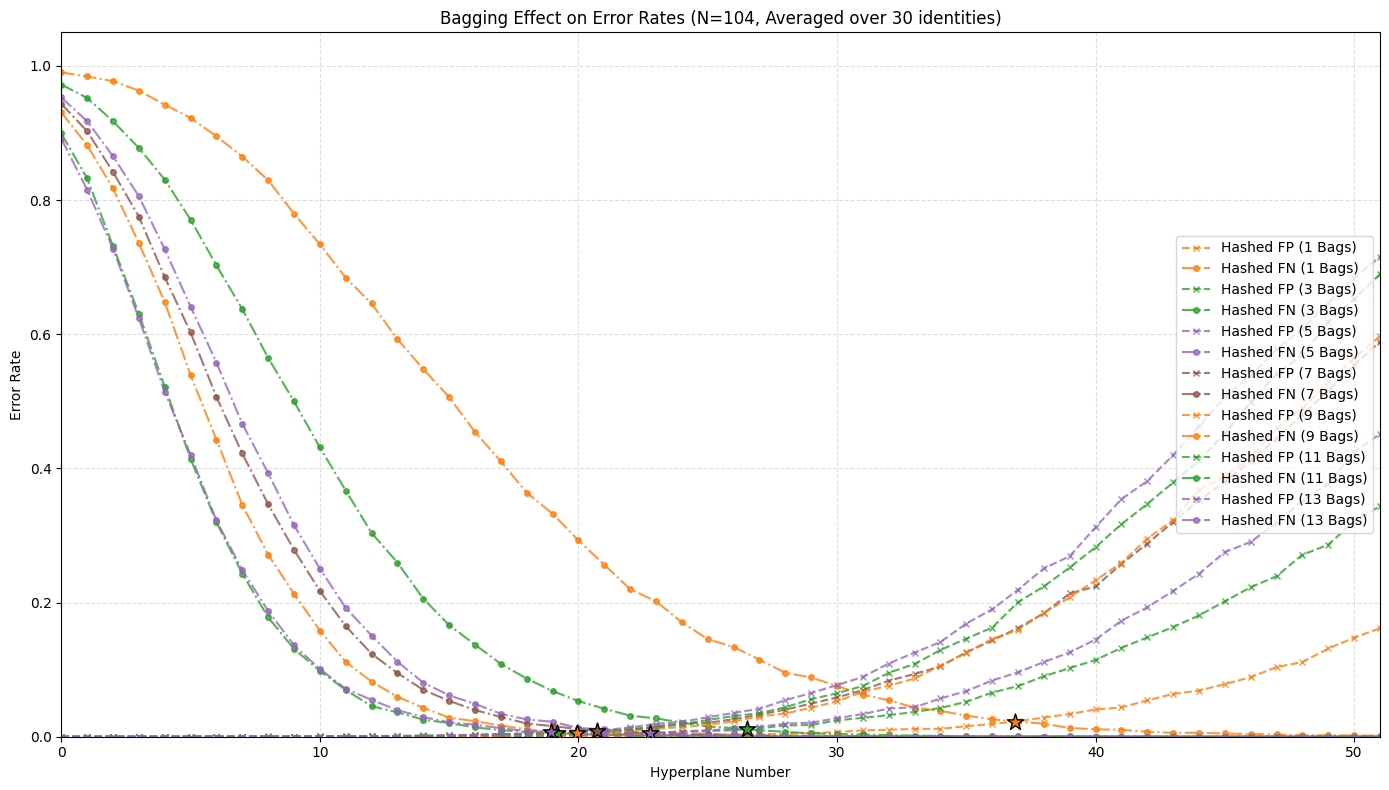

In [13]:
# --- 2. Plotting the Comparison ---
plt.figure(figsize=(14, 8))

# Define colors for the hashed bags to distinct them
colors = ['tab:orange', 'tab:green', 'tab:purple', 'tab:brown']

# Loop through our results to plot Hashed Curves
for idx, b in enumerate(test_bags_list):
    color = colors[idx % len(colors)]
    
    # Plot Hashed FP
    plt.plot(x_axis, results[b]['fp_hash'], 
             label=f'Hashed FP ({b} Bags)', 
             color=color, linestyle='--', marker='x', markersize=4, alpha=0.8)
    
    # Plot Hashed FN
    plt.plot(x_axis, results[b]['fn_hash'], 
             label=f'Hashed FN ({b} Bags)', 
             color=color, linestyle='-.', marker='o', markersize=4, alpha=0.8)
    
    # Mark the crossover point
    cx, cy = results[b]['cross_hash']
    if cx:
        plt.scatter([cx], [cy], color=color, s=150, marker='*', zorder=10, edgecolor='black')

# Formatting
plt.title(f'Bagging Effect on Error Rates (N={test_N}, Averaged over {test_people} identities)')
# plt.xlabel('Angles (Degrees)')
plt.xlabel('Hyperplane Number')
plt.ylabel('Error Rate')
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(0, max(x_axis))
plt.ylim(0, 1.05)
plt.legend(loc='center right') # Move legend if it covers data

plt.tight_layout()
plt.show()

### Test on quantization ####

In [ ]:
# --- Parameters ---
test_N = 80     
test_people = 30 
test_bags_list = [1, 3, 5, 7, 9, 11, 13] 
k_bits_list = [None, 16, 12, 8, 4, 3] # note the minimum has to be 2 bits but 2 will be too small that yield error! (0,1 only remember)

# Single list to hold our summary data
crossover_results = []

print(f"=== Starting Quantization & Bagging EER Grid ===")
print(f"Hyperplanes(N): {test_N} | People: {test_people}")
print(f"Combinations: {len(test_bags_list)} Bags x {len(k_bits_list)} Bit Depths")

# --- 1. Run Experiments ---
for b in test_bags_list:
    print(f"\n======================================================")
    print(f"                TESTING BAGS: {b}")
    print(f"======================================================")
    
    for k in k_bits_list:
        bit_label = f"{k}-bit" if k is not None else "Float"
        print(f"\n--- Running: {b} Bags at {bit_label} ---")
        
        # Execute the experiment
        res = run_multi_person_hyperplane_experiment(
            hyperplane=test_N, 
            bag_number=b, 
            num_people=test_people,
            probablistic=False,
            k_bits=k 
        )
        avg_fp_hash, avg_fn_hash, avg_fp_reg, avg_fn_reg, x_axis = res
        
        # Calculate Crossovers (EER)
        cross_x, cross_y = find_crossover(x_axis, avg_fp_hash, avg_fn_hash)
        cross_x_reg, cross_y_reg = find_crossover(x_axis, avg_fp_reg, avg_fn_reg)
        
        # Store the Crossover Data
        crossover_results.append({
            'Bags': b,
            'Quantization': bit_label,
            'Hashed_EER_Filter_Level': cross_x if cross_x is not None else "None",
            'Hashed_EER_Rate': cross_y if cross_y is not None else "None",
            'Theory_EER_Filter_Level': cross_x_reg if cross_x_reg is not None else "None",
            'Theory_EER_Rate': cross_y_reg if cross_y_reg is not None else "None"
        })
        
        # Quick console feedback
        if cross_y is not None:
            print(f"  > Hashed EER: {cross_y:.4f} (at {cross_x:.2f} hyperplanes discarded)")
        else:
            print(f"  > Hashed EER: No Intersection")

# --- 2. Save to CSV ---
print("\n=== Processing Complete! Saving to CSV... ===")

# Create DataFrame
df_crossovers = pd.DataFrame(crossover_results)

# Save to disk
output_filename = "quantization_eer_crossovers.csv"
df_crossovers.to_csv(output_filename, index=False)

print(f"Saved crossover results to: {output_filename}")

# Display the table right away in your notebook/console
display(df_crossovers)

=== Starting Quantization & Bagging EER Grid ===
Hyperplanes(N): 80 | People: 30
Combinations: 7 Bags x 6 Bit Depths

                TESTING BAGS: 1

--- Running: 1 Bags at Float ---


Testing 30 People (k=Float): 100%|██████████| 30/30 [05:17<00:00, 10.59s/it]


  > Hashed EER: 0.0306 (at 25.89 hyperplanes discarded)

--- Running: 1 Bags at 16-bit ---


Testing 30 People (k=16): 100%|██████████| 30/30 [15:01<00:00, 30.06s/it]


  > Hashed EER: 0.0329 (at 25.96 hyperplanes discarded)

--- Running: 1 Bags at 12-bit ---


...

Testing 30 People (k=3): 100%|██████████| 30/30 [12:48<00:00, 25.60s/it]


  > Hashed EER: No Intersection

                TESTING BAGS: 3

--- Running: 3 Bags at Float ---


Testing 30 People (k=Float): 100%|██████████| 30/30 [08:17<00:00, 16.57s/it]


  > Hashed EER: 0.0193 (at 17.86 hyperplanes discarded)

--- Running: 3 Bags at 16-bit ---


Testing 30 People (k=16):  73%|███████▎  | 22/30 [21:21<07:08, 53.62s/it]

### THE FP/FN sanity check after quantization ###

IDEA: after the quantization, the input vector(s) become corase so FN jumps really fast, while FP jumps up as well but slower

We will fix the following parameter 
- N, bags
- We will test quantization bits 12, 8, 4

In [ ]:
# --- Parameters ---
test_N = 96
test_bags = 1       # Change to 3 or 5 later to see the "rescue" effect!
test_people = 30    # 10 is usually enough for a relatively smooth plot
k_bits_list = [None, 12, 8, 4]

# Styling for the plot
colors = ['black', 'blue', 'green', 'red']
labels = ['Float', '12-bit', '8-bit', '4-bit']

# Dictionary to store the curves
plot_data = {}

print(f"=== Starting Curve Visualization Experiment ===")
print(f"Hyperplanes: {test_N} | Bags: {test_bags} | People: {test_people}\n")

# --- 1. Run the Experiments ---
for idx, k in enumerate(k_bits_list):
    bit_label = labels[idx]
    print(f"--- Running Simulation: {bit_label} ---")
    
    # Execute the experiment
    res = run_multi_person_hyperplane_experiment(
        hyperplane=test_N, 
        bag_number=test_bags, 
        num_people=test_people,
        probablistic=False,
        k_bits=k 
    )
    
    # Unpack the results
    avg_fp_hash, avg_fn_hash, avg_fp_reg, avg_fn_reg, x_axis = res
    
    # Save for plotting
    plot_data[bit_label] = {
        'fp': avg_fp_hash,
        'fn': avg_fn_hash,
        'x': x_axis,
        'color': colors[idx]
    }

print("\n=== Simulations Complete. Generating Plot... ===")

# --- 2. Plot the Curves ---
plt.figure(figsize=(12, 8))

for label, data in plot_data.items():
    x = data['x']
    c = data['color']
    
    # Plot False Positives (Solid Line)
    plt.plot(x, data['fp'], color=c, linestyle='-', linewidth=2, label=f'FP ({label})')
    
    # Plot False Negatives (Dashed Line)
    plt.plot(x, data['fn'], color=c, linestyle='--', linewidth=2, label=f'FN ({label})')

# Formatting the graph
plt.title(f"FP / FN Curves Under Quantization Distortion\n(N={test_N}, Bags={test_bags})", fontsize=14)
plt.xlabel("Discarded Hyperplanes (Intersection Threshold)", fontsize=12)
plt.ylabel("Error Rate (0.0 to 1.0)", fontsize=12)

# Set Y-axis limit to 1.0 (100% error) to see how high FN flies
plt.ylim(-0.02, 1.05) 

# Create a clean legend
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=10)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()